In [15]:
import subprocess
subprocess.run(['pip', 'install', 'pandas', 'numpy', 'matplotlib', 'seaborn',
                'scikit-learn', 'nltk', 'wordcloud', 'streamlit'], check=True)
print('✅ All libraries installed successfully!')


✅ All libraries installed successfully!


In [13]:

# ▶ Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import warnings
warnings.filterwarnings('ignore')

# Download NLTK resources (only needed once)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

print('✅ Libraries imported successfully!')


✅ Libraries imported successfully!


In [14]:

# ▶ Load the datasets
fake_df = pd.read_csv('Fake.csv')
true_df = pd.read_csv('True.csv')

# Add labels: 0 = Fake, 1 = Real
fake_df['label'] = 0
true_df['label'] = 1

print(f'Fake news articles: {len(fake_df)}')
print(f'Real news articles: {len(true_df)}')
print(f'Total articles: {len(fake_df) + len(true_df)}')

Fake news articles: 23481
Real news articles: 21417
Total articles: 44898


In [6]:
# ▶ Preview the data
print('=== FAKE NEWS SAMPLE ===')
print(fake_df.head(3))
print('\n=== TRUE NEWS SAMPLE ===')
print(true_df.head(3))

=== FAKE NEWS SAMPLE ===
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   

                date  label  
0  December 31, 2017      0  
1  December 31, 2017      0  
2  December 30, 2017      0  

=== TRUE NEWS SAMPLE ===
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...

In [7]:

# ▶ Combine both datasets into one
df = pd.concat([fake_df, true_df], ignore_index=True)

# Shuffle the data so fake and real are mixed
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Combined dataset shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nLabel distribution:')
print(df['label'].value_counts())
print(f"\n0 = Fake News, 1 = Real News")


Combined dataset shape: (44898, 5)

Columns: ['title', 'text', 'subject', 'date', 'label']

Label distribution:
label
0    23481
1    21417
Name: count, dtype: int64

0 = Fake News, 1 = Real News


In [8]:

# ▶ Check for missing values
print('Missing values in each column:')
print(df.isnull().sum())

# Drop rows where title or text is missing
df = df.dropna(subset=['title', 'text'])
df = df.reset_index(drop=True)
print(f'\nDataset after removing nulls: {df.shape}')

Missing values in each column:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Dataset after removing nulls: (44898, 5)


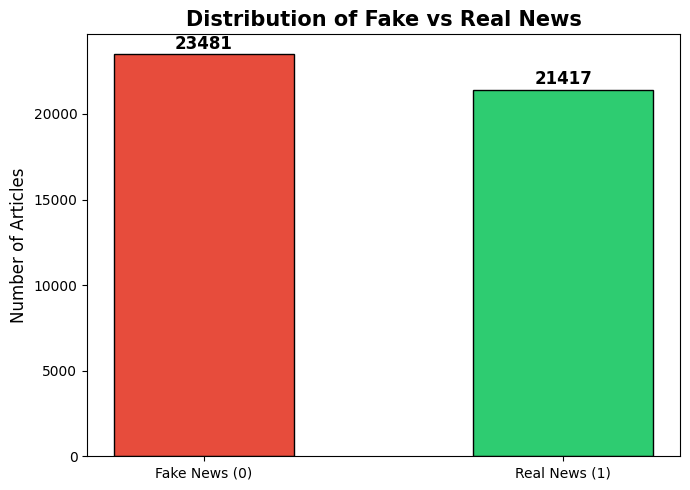

📊 Chart saved as class_distribution.png


In [9]:

# ▶ VISUALIZATION 1: Class Distribution Bar Chart
plt.figure(figsize=(7, 5))
colors = ['#e74c3c', '#2ecc71']
labels = ['Fake News (0)', 'Real News (1)']
counts = df['label'].value_counts().sort_index()

bars = plt.bar(labels, counts.values, color=colors, edgecolor='black', width=0.5)

# Add count labels on bars
for bar, count in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Distribution of Fake vs Real News', fontsize=15, fontweight='bold')
plt.ylabel('Number of Articles', fontsize=12)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print('📊 Chart saved as class_distribution.png')

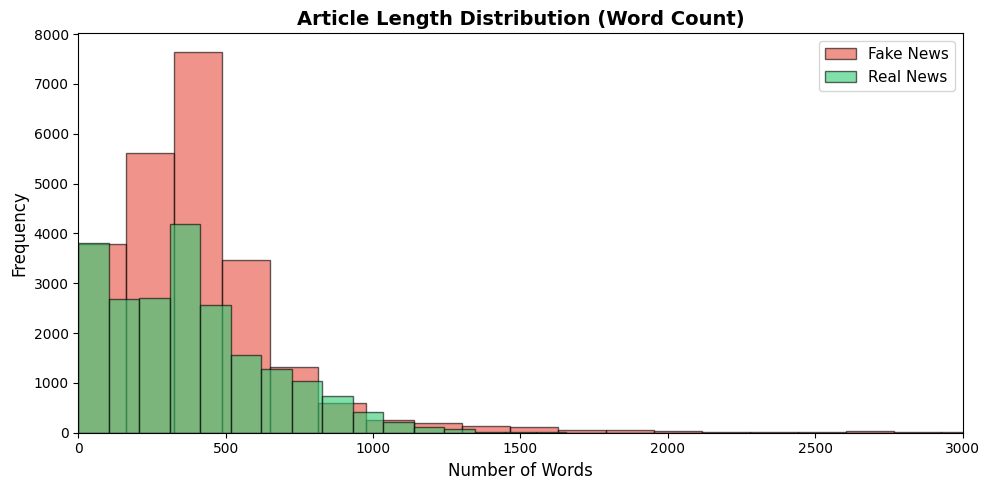

📊 Chart saved as length_distribution.png


In [10]:

# ▶ VISUALIZATION 2: Article Length Analysis
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
plt.hist(df[df['label']==0]['text_length'], bins=50, alpha=0.6,
         color='#e74c3c', label='Fake News', edgecolor='black')
plt.hist(df[df['label']==1]['text_length'], bins=50, alpha=0.6,
         color='#2ecc71', label='Real News', edgecolor='black')

plt.title('Article Length Distribution (Word Count)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=11)
plt.xlim(0, 3000)
plt.tight_layout()
plt.savefig('length_distribution.png', dpi=150)
plt.show()
print('📊 Chart saved as length_distribution.png')

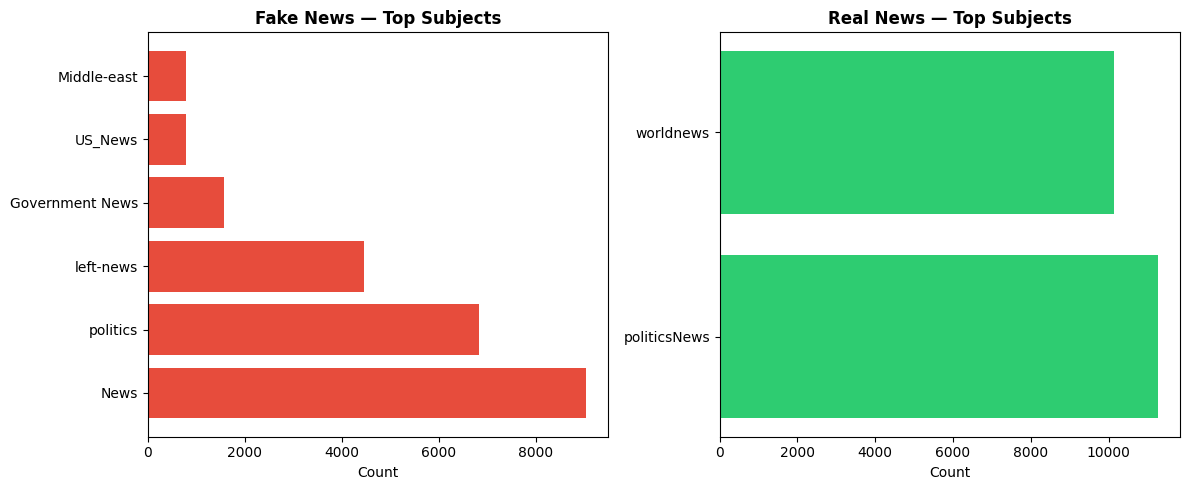

📊 Chart saved as subjects.png


In [11]:
# ▶ VISUALIZATION 3: Top News Subjects/Categories
if 'subject' in df.columns:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    fake_subjects = df[df['label']==0]['subject'].value_counts().head(6)
    plt.barh(fake_subjects.index, fake_subjects.values, color='#e74c3c')
    plt.title('Fake News — Top Subjects', fontweight='bold')
    plt.xlabel('Count')

    plt.subplot(1, 2, 2)
    true_subjects = df[df['label']==1]['subject'].value_counts().head(6)
    plt.barh(true_subjects.index, true_subjects.values, color='#2ecc71')
    plt.title('Real News — Top Subjects', fontweight='bold')
    plt.xlabel('Count')

    plt.tight_layout()
    plt.savefig('subjects.png', dpi=150)
    plt.show()
    print('📊 Chart saved as subjects.png')
else:
    print('No subject column found — skipping this chart.')

In [12]:

# ▶ Save the combined dataset for use in Step 2
df.to_csv('combined_news.csv', index=False)
print('✅ Combined dataset saved as combined_news.csv')
print('\n🎉 Step 1 Complete! Move on to Step2_Preprocessing_and_Model.ipynb')

✅ Combined dataset saved as combined_news.csv

🎉 Step 1 Complete! Move on to Step2_Preprocessing_and_Model.ipynb
